# **Tarea Examen 1**  
## **Nombre: Claudia Iriel Serrano Sánchez**  

### Física Computacional 2026-2
Resuelva los siguientes ejercicios.

1. Genere una función que se llame ```mi_plot(x,y,gap=1,label=" ")``` que haga la gráfica de una función no contínua y que no dibuje una línea vertical. Para ello utilice el parámetro ```gap``` para indicar cual sería la mínima discontinuidad que se debe tomar en cuenta para que el graficador no realice la línea vertical. Verifique el funcionamiento de su función con 3 ejemplos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_plot(x,y, gap=1, label=""):
    x_segmento = [x[0]]
    y_segmento = [y[0]]
    for i in range(1, len(x)):
        if abs(y[i] - y[i-1])>gap:
            plt.plot(x_segmento, y_segmento, label=label)
            x_segmento= []
            y_segmento= []
        x_segmento.append(x[i])
        y_segmento.append(y[i])
    plt.plot(x_segmento, y_segmento, label=label)

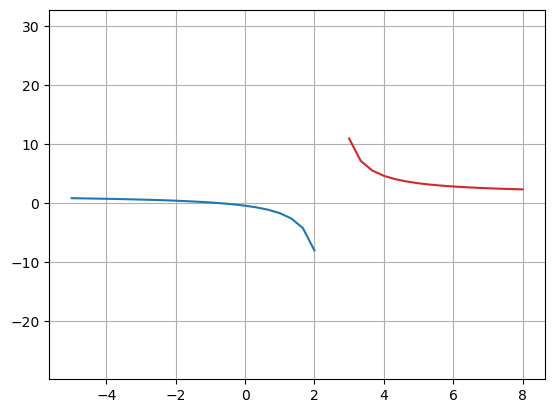

(None, None)

In [34]:
x = np.linspace(-5,8,40)
y = (3*x +2)/(2*x -5)
mi_plot(x,y, gap= 5, label= r"función 1")
plt.grid(), plt.show()

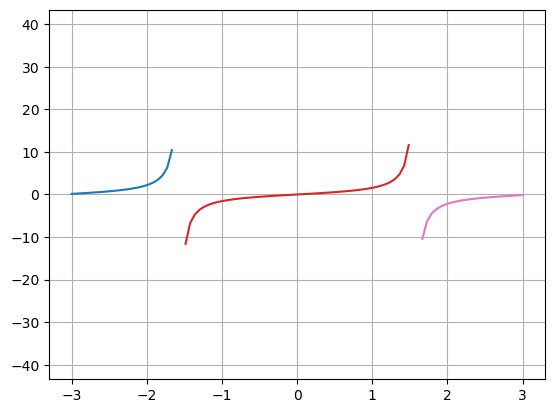

(None, None)

In [35]:
x = np.linspace(-3,3,100)
y = np.tan(x)
mi_plot(x,y, gap=5, label=r"función2:tan(x)")
plt.grid(), plt.show()

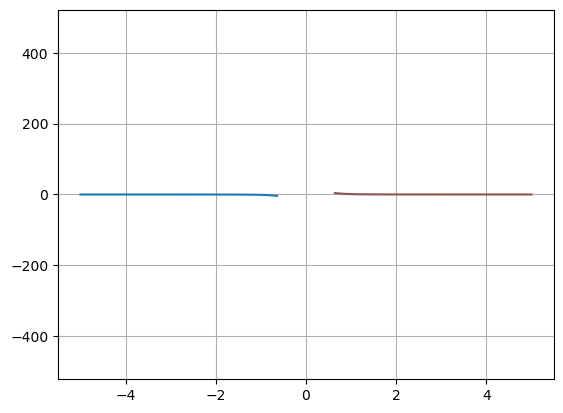

(None, None)

In [36]:
x = np.linspace(-5,5,40)
y = 1/(x**3)
mi_plot(x,y, gap=5, label="función3")
plt.grid(), plt.show()

2. Se tiene la siguiente función definida en el intervalo $[0,1]$:
$$
f(x)= \left\{ \begin{matrix}
{\rm Ai}(10x + ai_0 ) \textrm{ si } |x| \leq 1 \\ 
0 \textrm{ si } |x| > 1 \end{matrix} 
\right.
$$
donde $Ai(x)$ es la función de Airy, y $ai_0$ es la raíz de dicha función más cercana al cero. Defina una funcion $g(x)$ como la repetición periódica de dicha función para $x\in \mathbb{R}$. Verifique el resultado haciendo la gráfica de dicha función en el intervalo $[-10,10]$ o cualquier otro intervalo cuyo dominio sea mayor.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy

a_i0 = -2.3381

def f(x):
    if abs(x) <=1:
        return airy(10*x + a_i0)[0]
    else:
        return 0
        
f_vec = np.vectorize(f)

def g(x):
    x_mod = ((x+1)%2)-1
    return f(x_mod)

g_vec = np.vectorize(g)


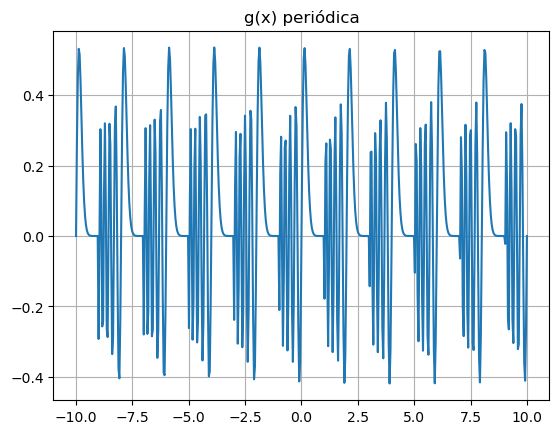

(None, None)

In [3]:
x = np.linspace(-10,10,500)
y = g_vec(x)
plt.plot(x,y)
plt.title(r'g(x) periódica')
plt.grid(), plt.show()

3. Dibuje la primera y segunda derivada de la función $g(x)$ del problema anterior en el intervalo $x \in [-10,10]$. 

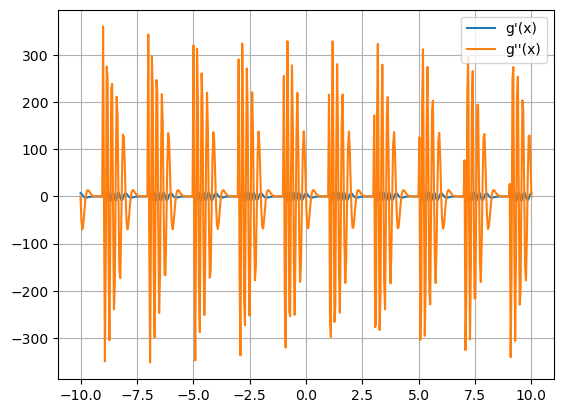

(<matplotlib.legend.Legend at 0x1186d0830>, None, None)

In [5]:
h= 1e-5

g1= (g_vec(x+h) - g_vec(x-h))/(2*h)
g2= (g_vec(x+h) - 2*g_vec(x) + g_vec(x-h))/(h**2)

plt.plot(x,g1, label=r"g'(x)")
plt.plot(x,g2, label=r"g''(x)")
plt.legend(), plt.grid(), plt.show()

4. Considere la siguiente suma:
$$
a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ ...}}}}
$$
Para hacer esta suma, vea lo que sucede con la suma a cada paso. Por ejemplo:

* Paso 1: $a = 1 + \frac{1}{2}$

* Paso 2: $a = 1 + \frac{1}{2+ \frac{1}{2}}$

* Paso 3: $a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2}}}$

Haga una función que calcule la suma para $N$ pasos. Haga la gráfica de la convergencia de la suma anterior, es decir, la gráfica que tenga en el eje $x$ los pasos y en el eje $y$ el valor de la suma. ¿Cómo se compara la suma con el valor de $\sqrt{2}$? y ¿Cuántos términos se tienen que tomar para que las variaciones en la suma sean menores a $1 \times 10^{-6}$?

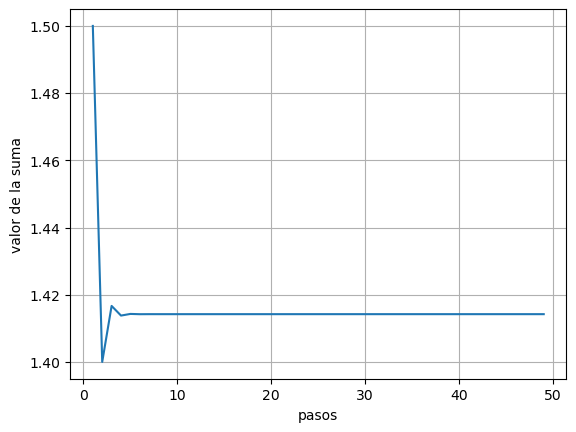

(None, None)

In [31]:
def suma(N):
    s = 0

    for i in range(N):
        s = 1/(2+s)
    return 1 + s

valores = []

for n in range(1,50):
    valores.append(suma(n))

plt.plot(range(1,50), valores)
plt.xlabel("pasos")
plt.ylabel("valor de la suma")
plt.grid(), plt.show()

In [32]:
import numpy as np

print(np.sqrt(2))

1.4142135623730951


In [33]:
n = 1

while True:
    if abs(suma(n) - suma(n-1))< 1e-6:
        print("N= ", n)
        break
    n+=1

N=  9
